In [4]:
import pandas as pd

df = pd.read_csv("D:\ml\machine-learning\student_success1.csv")

print ("sample rows")
print (df.head())

print("Dataset Shape")
print(f'Rows: {df.shape[0]}, columns: {df.shape[1]}')

print("Dataset info")
print(df.info())

print ("Summary Statistics")
print(df.describe(include="all"))

print ("Missing Values")
print (df.isnull().sum)



sample rows
   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           2          60         40      yes           5     no
1           5          80         60       no           6    yes
2           8          90         75      yes           8    yes
3           3          70         50      yes           5     no
4           7          85         70       no           7    yes
Dataset Shape
Rows: 20, columns: 6
Dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB
None
Summary Statistics
        StudyHours  Attendance  PastScore Internet  Sl

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\SUJAY\AppData\Local\Temp\ipykernel_19864\1805057535.py:3: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\ml\machine-learning\student_success1.csv")


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv ("D:\ml\machine-learning\student_success1.csv")

print("missing value in each column")
print(df.isnull().sum())

le = LabelEncoder()
df ['Internet'] = le.fit_transform(df["Internet"])
df ['Passed'] = le.fit_transform(df["Passed"])

print ("After Encoding")
print(df.head())

print("DATA-TYPE after cleaning")
print (df.dtypes)


missing value in each column
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
After Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           2          60         40         1           5       0
1           5          80         60         0           6       1
2           8          90         75         1           8       1
3           3          70         50         1           5       0
4           7          85         70         0           7       1
DATA-TYPE after cleaning
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object


<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\SUJAY\AppData\Local\Temp\ipykernel_19864\3177088986.py:4: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv ("D:\ml\machine-learning\student_success1.csv")


Clssification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\SUJAY\AppData\Local\Temp\ipykernel_19864\1492852938.py:10: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv ("D:\ml\machine-learning\student_success1.csv")


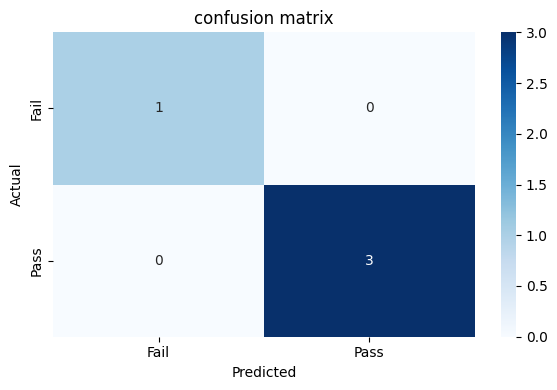

----predict your result----
an error occured The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Past_score
- Sleep_hours
- Study_hours
Feature names seen at fit time, yet now missing:
- PastScore
- SleepHours
- StudyHours



In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv ("D:\ml\machine-learning\student_success1.csv")

le = LabelEncoder()
df ['Internet'] = le.fit_transform(df["Internet"])
df ['Passed'] = le.fit_transform(df["Passed"])

features = ['StudyHours', 'Attendance','PastScore','SleepHours']
scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[features] = scaler.fit_transform(df[features])

x = df_scaled[features]
y = df_scaled['Passed']
x_train , x_test , y_train , y_test = train_test_split (x,y , test_size=0.2 ,random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print("Clssification report")
print(classification_report(y_test,y_pred))

conf_matrix = confusion_matrix (y_test , y_pred)
plt.figure(figsize=(6,4))
sns.heatmap (conf_matrix , annot= True , fmt="d" , cmap= "Blues" ,
            xticklabels=["Fail" , "Pass"] , yticklabels=["Fail","Pass"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion matrix")
plt.tight_layout()
plt.show()

print("----predict your result----")
try:
    Study_hours = float(input("Enter study hours :"))
    Attendance = float(input("Enter attendance :"))
    Past_score = float(input("Enter past score :"))
    Sleep_hours = float(input("Enter sleep hours :"))

    user_input_df = pd.DataFrame([{
        'Study_hours' : Study_hours,
        'Attendance' : Attendance,
        'Past_score' : Past_score,
        'Sleep_hours' : Sleep_hours
    }])

    user_input_scaler = scaler.transform(user_input_df)

    prediction  = model.predict(user_input_scaler)[0]

    result = "pass" if prediction == 1 else "fail" 
    print (f"prediction based on inpute : {result}")

except Exception as e:
    print("an error occured" , e)

